🎵 Music Data Clustering — Simplified Version

In [2]:

# Imports libaray
# -------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1️⃣ Load Data
# -------------------------------------------------------
df = pd.read_csv(r"C:\Users\11vij\OneDrive\Desktop\project 4\single_genre_artists.csv.csv")
print(f"Data shape: {df.shape}")
print(df.dtypes)

Data shape: (95837, 23)
id_songs               object
name_song              object
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers             float64
genres                 object
name_artists           object
popularity_artists      int64
dtype: object


In [4]:
#2️⃣ Select Audio Features & Clean
# -------------------------------------------------------
audio_cols = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    'duration_ms', 'popularity_songs'
]

features = df[audio_cols].dropna()

In [5]:
# 3️⃣ Scale Data
# -------------------------------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled, columns=audio_cols)

In [6]:
# 4️⃣ PCA for 2D Visualization
# -------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.20399788 0.13667721]


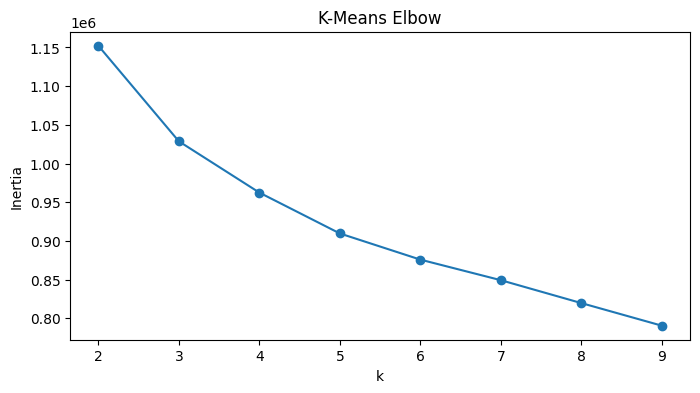

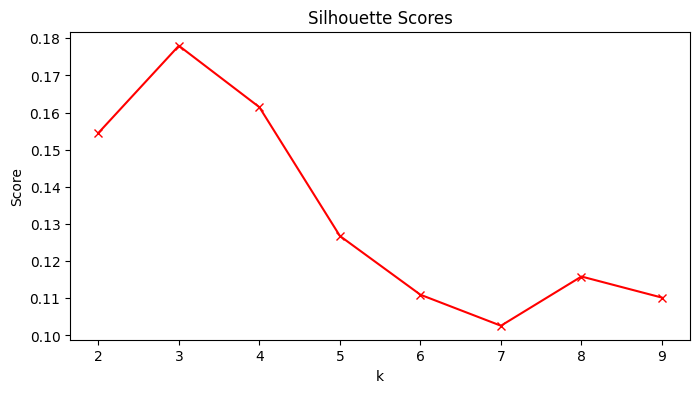

In [8]:
# 5️⃣ K-Means Clustering (Elbow & Silhouette)
# -------------------------------------------------------
K = range(2, 10)
inertias, sil_scores = [], []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(scaled_df)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_df, preds))

plt.figure(figsize=(8,4))
plt.plot(K, inertias, 'o-')
plt.title("K-Means Elbow")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K, sil_scores, 'x-r')
plt.title("Silhouette Scores")
plt.xlabel("k"); plt.ylabel("Score")
plt.show()

# Choose final k (based on elbow or silhouette)
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_df)


In [ ]:
# 6️⃣ Alternative Models
# -------------------------------------------------------
dbscan = DBSCAN(eps=0.5, min_samples=10)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_df)

agglo = AgglomerativeClustering(n_clusters=5)
df['agglo_cluster'] = agglo.fit_predict(scaled_df)

In [1]:
# 7️⃣ Evaluate Clusters
# -------------------------------------------------------
print("\n--- Evaluation ---")
print("KMeans Silhouette:", silhouette_score(scaled_df, df['kmeans_cluster']))
print("KMeans DB Index:", davies_bouldin_score(scaled_df, df['kmeans_cluster']))

if len(set(df['dbscan_cluster'])) > 1:
    mask = df['dbscan_cluster'] != -1
    print("DBSCAN Silhouette:", silhouette_score(scaled_df[mask], df['dbscan_cluster'][mask]))

print("Agglomerative Silhouette:", silhouette_score(scaled_df, df['agglo_cluster']))


--- Evaluation ---


NameError: name 'silhouette_score' is not defined

In [ ]:
# 8️⃣ Cluster Profiles
# -------------------------------------------------------
profiles = df.groupby('kmeans_cluster')[audio_cols].mean()
print("\nCluster Profiles:\n", profiles)

In [ ]:
# 9️⃣ Visualizations
# -------------------------------------------------------
# PCA Scatter
pca_df['cluster'] = df['kmeans_cluster']
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=pca_df, palette='tab10')
plt.title('KMeans Clusters (PCA Projection)')
plt.show()

# Feature Averages
profiles.plot(kind='bar', figsize=(12,6))
plt.title('Average Audio Features per Cluster')
plt.ylabel('Mean Value')
plt.show()

# Example Distribution
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='tempo', hue='kmeans_cluster', palette='tab10')
plt.title('Tempo Distribution by Cluster')
plt.show()

In [ ]:
# 🔟 Export Results
# -------------------------------------------------------
df.to_csv('single_genre_artists_clustered.csv', index=False)
profiles.to_csv('cluster_summary.csv')
print("✅ Exported labeled dataset and cluster summary.")